# 풍력발전량 예측
## 전처리 파이프라인: 가장 가까운 기상 격자 → 발전량

In [243]:
import pandas as pd
import numpy as np
from pathlib import Path

BASE = Path('open')
TRAIN = BASE / 'train'
TEST  = BASE / 'test'

## 1. info.xlsx — 터빈 위치 및 KPX 그룹 확인

In [244]:
info = pd.read_excel(BASE / 'info.xlsx', header=3)
# 첫 번째 빈 컬럼 제거
info = info.iloc[:, 1:].reset_index(drop=True)
# KPX그룹은 병합 셀 → ffill로 채우기
info['KPX그룹'] = info['KPX그룹'].ffill().astype(int)
print(info.shape)
print(info.columns.tolist())
info

(17, 11)
['단계', '명칭', '제작사', '모델명', '호기', '좌표(Google)', 'KPX그룹', 'Hub Height(m)', 'Rotor Diameter(m)', '설비용량(MW)', '그룹설비용량(MW)']


,단계,명칭,제작사,모델명,호기,좌표(Google),KPX그룹,Hub Height(m),Rotor Diameter(m),설비용량(MW),그룹설비용량(MW)
0,1,태백가덕산,VESTAS,V126,1,"37°16'55.61""N 128°57'02.10""E",1,117,126,3.6,21.6
1,1,태백가덕산,VESTAS,V126,2,"37°17'04.05""N 128°56'58.35""E",1,117,126,3.6,NaN
2,1,태백가덕산,VESTAS,V126,3,"37°17'11.49""N 128°56'58.99""E",1,117,126,3.6,NaN
3,1,태백가덕산,VESTAS,V126,4,"37°17'23.11""N 128°57'03.68""E",1,117,126,3.6,NaN
4,1,태백가덕산,VESTAS,V126,5,"37°17'28.20""N 128°57'15.58""E",1,117,126,3.6,NaN
5,1,태백가덕산,VESTAS,V126,6,"37°17'19.48""N 128°57'24.96""E",1,117,126,3.6,NaN
6,1,태백가덕산,VESTAS,V126,7,"37°17'16.20""N 128°57'34.67""E",2,117,126,3.6,21.6
7,1,태백가덕산,VESTAS,V126,8,"37°17'11.29""N 128°57'47.24""E",2,117,126,3.6,NaN
8,1,태백가덕산,VESTAS,V126,9,"37°17'00.97""N 128°57'57.44""E",2,117,126,3.6,NaN
9,1,태백가덕산,VESTAS,V126,10,"37°16'52.77""N 128°58'04.18""E",2,117,126,3.6,NaN


In [245]:
# KPX 그룹별 터빈 수 확인
print(info.groupby('KPX그룹')[['명칭','제작사','호기']].count())

       명칭  제작사  호기
KPX그룹             
1       6    6   6
2       6    6   6
3       5    5   5


In [246]:
import re

def dms_to_dd(dms_str):
    """'37°16'55.61\"N 128°57'02.10\"E' → (lat, lon)"""
    # °를 다양한 인코딩으로 매칭
    pattern = r"(\d+)[^\d](\d+)'([\d.]+)\"([NS])\s+(\d+)[^\d](\d+)'([\d.]+)\"([EW])"
    m = re.search(pattern, str(dms_str))
    if not m:
        return None, None
    lat = int(m.group(1)) + int(m.group(2))/60 + float(m.group(3))/3600
    lon = int(m.group(5)) + int(m.group(6))/60 + float(m.group(7))/3600
    if m.group(4) == 'S': lat = -lat
    if m.group(8) == 'W': lon = -lon
    return lat, lon

coord_col = '좌표(Google)'
grp_col   = 'KPX그룹'

parsed = info[coord_col].apply(dms_to_dd)
info[['lat', 'lon']] = pd.DataFrame(parsed.tolist(), index=info.index)

print(info[[grp_col, '명칭', '호기', 'lat', 'lon']].to_string())

    KPX그룹     명칭  호기        lat         lon
0       1  태백가덕산   1  37.282114  128.950583
1       1  태백가덕산   2  37.284458  128.949542
2       1  태백가덕산   3  37.286525  128.949719
3       1  태백가덕산   4  37.289753  128.951022
4       1  태백가덕산   5  37.291167  128.954328
5       1  태백가덕산   6  37.288744  128.956933
6       2  태백가덕산   7  37.287833  128.959631
7       2  태백가덕산   8  37.286469  128.963122
8       2  태백가덕산   9  37.283603  128.965956
9       2  태백가덕산  10  37.281325  128.967828
10      2  태백가덕산  11  37.279136  128.966978
11      2  태백가덕산  12  37.275161  128.967372
12      3  태백가덕산   1  37.283258  128.962492
13      3   태백원동   2  37.277892  128.970500
14      3   태백원동   3  37.274453  128.972928
15      3   태백원동   4  37.271828  128.974725
16      3   태백원동   5  37.268564  128.976578


In [247]:
# KPX 그룹별 터빈 위치 중심점
group_center = (
    info.groupby(grp_col)[['lat', 'lon']]
    .mean()
    .reset_index()
    .rename(columns={grp_col: 'kpx_group'})
)
print(group_center)

   kpx_group        lat         lon
0          1  37.287127  128.952021
1          2  37.282255  128.965148
2          3  37.275199  128.971444


## 2. LDAPS/GFS 격자 위치 확인

In [248]:
ldaps_raw = pd.read_csv(TRAIN / 'ldaps_train.csv', encoding='utf-8-sig', parse_dates=['forecast_kst_dtm'])
print('LDAPS shape:', ldaps_raw.shape)

ldaps_grids = ldaps_raw[['grid_id', 'latitude', 'longitude']].drop_duplicates().reset_index(drop=True)
print(f'LDAPS 격자 수: {len(ldaps_grids)}')
print(ldaps_grids)

LDAPS shape: (420864, 35)
LDAPS 격자 수: 16
    grid_id  latitude  longitude
0         1   37.3032   128.9443
1         2   37.3027   128.9617
2         3   37.3022   128.9790
3         4   37.2899   128.9263
4         5   37.2894   128.9437
5         6   37.2888   128.9610
6         7   37.2883   128.9784
7         8   37.2878   128.9958
8         9   37.2760   128.9257
9        10   37.2755   128.9430
10       11   37.2750   128.9604
11       12   37.2745   128.9778
12       13   37.2740   128.9951
13       14   37.2617   128.9424
14       15   37.2612   128.9598
15       16   37.2607   128.9771


In [249]:
gfs_raw = pd.read_csv(TRAIN / 'gfs_train.csv', encoding='utf-8-sig', parse_dates=['forecast_kst_dtm'])
print('GFS shape:', gfs_raw.shape)

gfs_grids = gfs_raw[['grid_id', 'latitude', 'longitude']].drop_duplicates().reset_index(drop=True)
print(f'GFS 격자 수: {len(gfs_grids)}')
print(gfs_grids)

GFS shape: (236736, 40)
GFS 격자 수: 9
   grid_id  latitude  longitude
0        1     37.50     128.75
1        2     37.50     129.00
2        3     37.50     129.25
3        4     37.25     128.75
4        5     37.25     129.00
5        6     37.25     129.25
6        7     37.00     128.75
7        8     37.00     129.00
8        9     37.00     129.25


## 3. KPX 그룹별 최근접 격자 탐색

In [250]:
def haversine(lat1, lon1, lat2, lon2):
    R = 6371
    dlat = np.radians(lat2 - lat1)
    dlon = np.radians(lon2 - lon1)
    a = np.sin(dlat/2)**2 + np.cos(np.radians(lat1)) * np.cos(np.radians(lat2)) * np.sin(dlon/2)**2
    return R * 2 * np.arcsin(np.sqrt(a))

def find_nearest_grid(center_lat, center_lon, grids_df):
    dists = haversine(center_lat, center_lon, grids_df['latitude'].values, grids_df['longitude'].values)
    idx = np.argmin(dists)
    return grids_df.iloc[idx]['grid_id'], dists[idx]

In [251]:
nearest = []
for _, row in group_center.iterrows():
    ldaps_gid, ldaps_dist = find_nearest_grid(row['lat'], row['lon'], ldaps_grids)
    gfs_gid,   gfs_dist   = find_nearest_grid(row['lat'], row['lon'], gfs_grids)
    nearest.append({
        'kpx_group': row['kpx_group'],
        'lat': row['lat'], 'lon': row['lon'],
        'ldaps_grid_id': ldaps_gid, 'ldaps_dist_km': round(ldaps_dist, 2),
        'gfs_grid_id':   gfs_gid,   'gfs_dist_km':   round(gfs_dist, 2),
    })

nearest_df = pd.DataFrame(nearest)
print(nearest_df.to_string())

   kpx_group        lat         lon  ldaps_grid_id  ldaps_dist_km  gfs_grid_id  gfs_dist_km
0        1.0  37.287127  128.952021            5.0           0.78          5.0         5.92
1        2.0  37.282255  128.965148            6.0           0.82          5.0         4.73
2        3.0  37.275199  128.971444           12.0           0.57          5.0         3.77


## 4. 최근접 격자 기상 피처 추출 + 풍속 파생 피처

In [252]:
def add_wind_speed(df, u_col, v_col, name):
    df[name] = np.sqrt(df[u_col]**2 + df[v_col]**2)
    return df

def add_wind_features(df, u_col, v_col, prefix):
    u, v = df[u_col], df[v_col]
    ws = np.sqrt(u**2 + v**2)
    df[f'{prefix}_ws']    = ws
    df[f'{prefix}_ws3']   = ws ** 3                        # 발전량 ∝ v³
    df[f'{prefix}_wd']    = np.degrees(np.arctan2(u, v)) % 360  # 풍향 (0~360°)
    df[f'{prefix}_wd_sin'] = np.sin(np.radians(df[f'{prefix}_wd']))  # 풍향 sin
    df[f'{prefix}_wd_cos'] = np.cos(np.radians(df[f'{prefix}_wd']))  # 풍향 cos
    return df

# LDAPS
ldaps_raw = add_wind_features(ldaps_raw, 'heightAboveGround_10_10u', 'heightAboveGround_10_10v', 'ws10')
ldaps_raw = add_wind_features(ldaps_raw, 'heightAboveGround_50_50MUmax', 'heightAboveGround_50_50MVmax', 'ws50max')
# 수직 바람 시어 (50m/10m 풍속 비율) → 고도별 풍속 변화
ldaps_raw['ws_shear'] = ldaps_raw['ws50max_ws'] / (ldaps_raw['ws10_ws'] + 0.1)
# 기존 컬럼 호환
ldaps_raw['ws_10m']    = ldaps_raw['ws10_ws']
ldaps_raw['ws_50m_max'] = ldaps_raw['ws50max_ws']

# GFS
gfs_raw = add_wind_features(gfs_raw, 'heightAboveGround_10_10u', 'heightAboveGround_10_10v', 'ws10')
gfs_raw = add_wind_features(gfs_raw, 'heightAboveGround_80_u',   'heightAboveGround_80_v',   'ws80')
gfs_raw = add_wind_features(gfs_raw, 'heightAboveGround_100_100u', 'heightAboveGround_100_100v', 'ws100')
gfs_raw['ws_shear'] = gfs_raw['ws80_ws'] / (gfs_raw['ws10_ws'] + 0.1)
gfs_raw['ws_10m']  = gfs_raw['ws10_ws']
gfs_raw['ws_80m']  = gfs_raw['ws80_ws']
gfs_raw['ws_100m'] = gfs_raw['ws100_ws']

print('풍속·풍향·v³ 파생 피처 추가 완료')
print('추가 피처:', [c for c in ldaps_raw.columns if c.startswith('ws')])

풍속·풍향·v³ 파생 피처 추가 완료
추가 피처: ['ws10_ws', 'ws10_ws3', 'ws10_wd', 'ws10_wd_sin', 'ws10_wd_cos', 'ws50max_ws', 'ws50max_ws3', 'ws50max_wd', 'ws50max_wd_sin', 'ws50max_wd_cos', 'ws_shear', 'ws_10m', 'ws_50m_max']


In [253]:
ldaps_feat_cols = [
    'forecast_kst_dtm', 'grid_id',
    'ws10_ws', 'ws10_ws3', 'ws10_wd_sin', 'ws10_wd_cos',
    'ws50max_ws', 'ws50max_ws3', 'ws50max_wd_sin', 'ws50max_wd_cos',
    'ws_shear',
    'heightAboveGround_2_t', 'heightAboveGround_2_r',
    'surface_0_NDNSW', 'etc_0_blh',
    'etc_0_lcc', 'etc_0_mcc', 'etc_0_hcc',
]

gfs_feat_cols = [
    'forecast_kst_dtm', 'grid_id',
    'ws10_ws', 'ws10_ws3', 'ws10_wd_sin', 'ws10_wd_cos',
    'ws80_ws', 'ws80_ws3', 'ws80_wd_sin', 'ws80_wd_cos',
    'ws100_ws', 'ws100_ws3',
    'ws_shear',
    'heightAboveGround_2_2t', 'heightAboveGround_2_2r',
    'surface_0_dswrf', 'surface_0_gust',
    'lowCloudLayer_0_lcc', 'atmosphere_0_tcc',
]

ldaps_feats = {}
gfs_feats   = {}

for _, row in nearest_df.iterrows():
    grp = row['kpx_group']
    avail_l = [c for c in ldaps_feat_cols if c in ldaps_raw.columns or c == 'forecast_kst_dtm' or c == 'grid_id']
    avail_g = [c for c in gfs_feat_cols   if c in gfs_raw.columns   or c == 'forecast_kst_dtm' or c == 'grid_id']

    ldaps_feats[grp] = (
        ldaps_raw[ldaps_raw['grid_id'] == row['ldaps_grid_id']][avail_l]
        .rename(columns=lambda c: f'ldaps_{c}' if c not in ['forecast_kst_dtm','grid_id'] else c)
        .drop(columns='grid_id')
    )
    gfs_feats[grp] = (
        gfs_raw[gfs_raw['grid_id'] == row['gfs_grid_id']][avail_g]
        .rename(columns=lambda c: f'gfs_{c}' if c not in ['forecast_kst_dtm','grid_id'] else c)
        .drop(columns='grid_id')
    )

print('피처 추출 완료')
print('LDAPS 피처:', [c for c in ldaps_feats[nearest_df.iloc[0]['kpx_group']].columns if c != 'forecast_kst_dtm'])

피처 추출 완료
LDAPS 피처: ['ldaps_ws10_ws', 'ldaps_ws10_ws3', 'ldaps_ws10_wd_sin', 'ldaps_ws10_wd_cos', 'ldaps_ws50max_ws', 'ldaps_ws50max_ws3', 'ldaps_ws50max_wd_sin', 'ldaps_ws50max_wd_cos', 'ldaps_ws_shear', 'ldaps_heightAboveGround_2_t', 'ldaps_heightAboveGround_2_r', 'ldaps_surface_0_NDNSW', 'ldaps_etc_0_blh', 'ldaps_etc_0_lcc', 'ldaps_etc_0_mcc', 'ldaps_etc_0_hcc']


## 5. train_labels 병합

In [254]:
labels = pd.read_csv(TRAIN / 'train_labels.csv', encoding='utf-8-sig', parse_dates=['kst_dtm'])
print('labels shape:', labels.shape)
print(labels.isnull().sum())
labels.head(3)

labels shape: (26304, 4)
kst_dtm           0
kpx_group_1     104
kpx_group_2     103
kpx_group_3    8766
dtype: int64


,kst_dtm,kpx_group_1,kpx_group_2,kpx_group_3
0,2022-01-01 01:00:00,12004.421,9719.242,NaN
1,2022-01-01 02:00:00,12901.137,10297.768,NaN
2,2022-01-01 03:00:00,12091.200,10731.663,NaN


## 5-0. SCADA 분석 — 실제 Cut-in 풍속 도출

In [255]:
scada_v = pd.read_csv(TRAIN / 'scada_vestas_train.csv', encoding='utf-8-sig', parse_dates=['kst_dtm'])
scada_u = pd.read_csv(TRAIN / 'scada_unison_train.csv', encoding='utf-8-sig', parse_dates=['kst_dtm'])

print('VESTAS columns:', scada_v.columns.tolist())
print('UNISON columns:', scada_u.columns.tolist())

VESTAS columns: ['kst_dtm', 'vestas_wtg01_power_kw10m', 'vestas_wtg02_power_kw10m', 'vestas_wtg03_power_kw10m', 'vestas_wtg04_power_kw10m', 'vestas_wtg05_power_kw10m', 'vestas_wtg06_power_kw10m', 'vestas_wtg07_power_kw10m', 'vestas_wtg08_power_kw10m', 'vestas_wtg09_power_kw10m', 'vestas_wtg10_power_kw10m', 'vestas_wtg11_power_kw10m', 'vestas_wtg12_power_kw10m', 'vestas_wtg01_ws', 'vestas_wtg02_ws', 'vestas_wtg03_ws', 'vestas_wtg04_ws', 'vestas_wtg05_ws', 'vestas_wtg06_ws', 'vestas_wtg07_ws', 'vestas_wtg08_ws', 'vestas_wtg09_ws', 'vestas_wtg10_ws', 'vestas_wtg11_ws', 'vestas_wtg12_ws', 'vestas_wtg01_wd', 'vestas_wtg02_wd', 'vestas_wtg03_wd', 'vestas_wtg04_wd', 'vestas_wtg05_wd', 'vestas_wtg06_wd', 'vestas_wtg07_wd', 'vestas_wtg08_wd', 'vestas_wtg09_wd', 'vestas_wtg10_wd', 'vestas_wtg11_wd', 'vestas_wtg12_wd']
UNISON columns: ['kst_dtm', 'unison_wtg01_power_kw10m', 'unison_wtg02_power_kw10m', 'unison_wtg03_power_kw10m', 'unison_wtg04_power_kw10m', 'unison_wtg05_power_kw10m', 'unison_wtg0

In [256]:
# KPX 그룹별 터빈 매핑 (info.xlsx 기준)
# group 1: VESTAS 1-6호기, group 2: VESTAS 7-12호기, group 3: UNISON 1-5호기
grp_turbines = {
    'kpx_group_1': [f'vestas_wtg0{i}' for i in range(1, 7)],
    'kpx_group_2': [f'vestas_wtg{i:02d}' for i in range(7, 13)],
    'kpx_group_3': [f'unison_wtg0{i}' for i in range(1, 6)],
}

# SCADA: 10분 단위 → 1시간 집계
def scada_hourly(df, turbines):
    ws_cols    = [f'{t}_ws'         for t in turbines if f'{t}_ws' in df.columns]
    power_cols = [f'{t}_power_kw10m' for t in turbines if f'{t}_power_kw10m' in df.columns]
    agg = df.set_index('kst_dtm')[ws_cols + power_cols].resample('1h').mean()
    agg['ws_mean']    = agg[ws_cols].mean(axis=1)
    agg['power_mean'] = agg[power_cols].mean(axis=1)
    return agg[['ws_mean', 'power_mean']].reset_index()

scada_grp = {
    'kpx_group_1': scada_hourly(scada_v, grp_turbines['kpx_group_1']),
    'kpx_group_2': scada_hourly(scada_v, grp_turbines['kpx_group_2']),
    'kpx_group_3': scada_hourly(scada_u, grp_turbines['kpx_group_3']),
}
print('SCADA 집계 완료')
scada_grp['kpx_group_1'].head()

SCADA 집계 완료


,kst_dtm,ws_mean,power_mean
0,2022-01-01 01:00:00,8.480556,353.805556
1,2022-01-01 02:00:00,8.347222,348.805556
2,2022-01-01 03:00:00,9.333333,451.000000
3,2022-01-01 04:00:00,10.452778,539.250000
4,2022-01-01 05:00:00,10.144444,482.722222


## 5-0b. SCADA 파워커브 피팅 → LDAPS 풍속에 적용

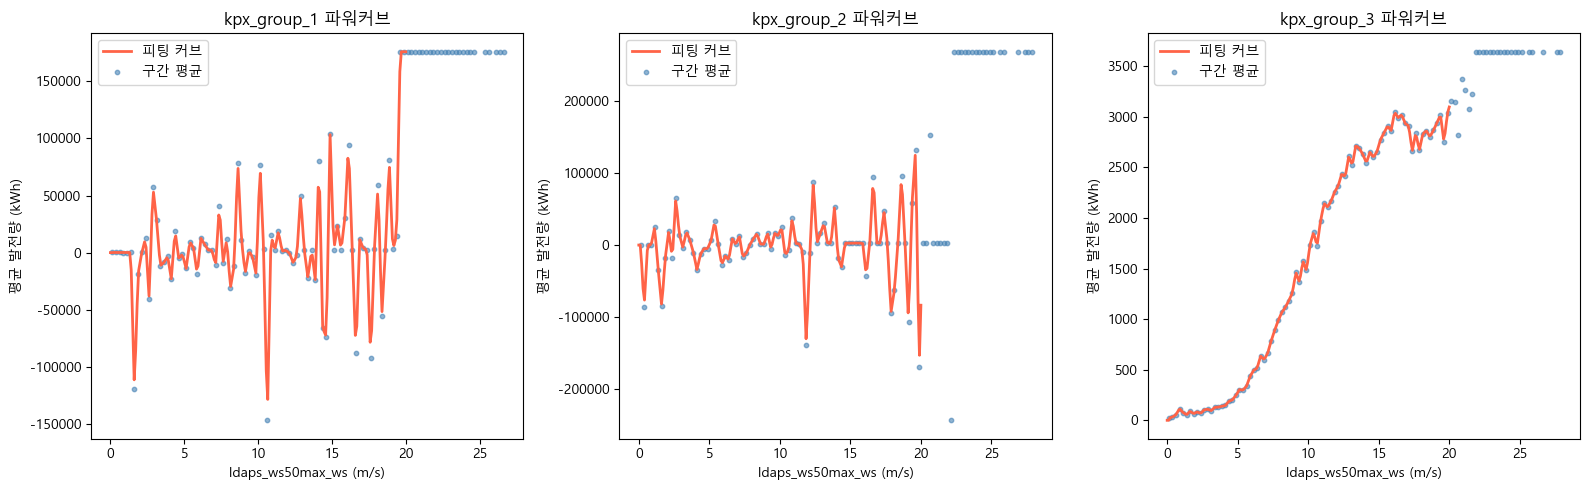

파워커브 피팅 완료: ['kpx_group_1', 'kpx_group_2', 'kpx_group_3']


In [257]:
from scipy.interpolate import interp1d
import matplotlib.pyplot as plt

# capacities 미리 정의 (cell_model 이전에도 사용)
capacities = {'kpx_group_1': 21600, 'kpx_group_2': 21600, 'kpx_group_3': 21000}

# get_ws_col: 실제 컬럼명 자동 탐지 (미리 정의)
def get_ws_col(df):
    for c in ['ldaps_ws50max_ws', 'ldaps_ws_50m_max', 'ldaps_ws10_ws', 'ldaps_ws_10m']:
        if c in df.columns:
            return c
    return None

def fit_power_curve(scada_df, ldaps_df, label_col, ws_col='ldaps_ws50max_ws', bin_size=0.25):
    sc = scada_df.dropna().copy()
    ldf = ldaps_df[['kst_dtm', ws_col, label_col]].dropna().copy()
    sc['power_kwh'] = sc['power_mean'] * 6  # kW10m → kWh

    merged = ldf.merge(sc[['kst_dtm', 'power_kwh']], on='kst_dtm', how='inner')
    merged = merged[merged[ws_col] >= 0]

    bins = np.arange(0, merged[ws_col].max() + bin_size, bin_size)
    merged['ws_bin'] = pd.cut(merged[ws_col], bins=bins)
    curve = merged.groupby('ws_bin')['power_kwh'].mean()

    ws_mid = np.array([b.mid for b in curve.index])
    pw_val = curve.values
    valid = ~np.isnan(pw_val)
    ws_mid, pw_val = ws_mid[valid], pw_val[valid]

    rated_idx = np.argmax(pw_val)
    pw_val[rated_idx:] = pw_val[rated_idx]

    interp_fn = interp1d(ws_mid, pw_val, kind='linear',
                         bounds_error=False, fill_value=(0, pw_val[rated_idx]))
    return interp_fn, ws_mid, pw_val

# ── 이 셀은 cell_merge(train_datasets 생성) 이후에 실행하세요 ──
power_curves = {}
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for i, label_col in enumerate(['kpx_group_1', 'kpx_group_2', 'kpx_group_3']):
    ws_col = get_ws_col(train_datasets[label_col])
    if ws_col is None:
        print(f'{label_col}: 풍속 컬럼 없음')
        continue

    df_train = train_datasets[label_col][['kst_dtm', ws_col, label_col]]
    fn, ws_pts, pw_pts = fit_power_curve(
        scada_grp[label_col], df_train, label_col, ws_col=ws_col
    )
    power_curves[label_col] = {'fn': fn, 'ws_col': ws_col}

    ws_plot = np.linspace(0, 20, 200)
    axes[i].plot(ws_plot, fn(ws_plot), color='tomato', linewidth=2, label='피팅 커브')
    axes[i].scatter(ws_pts, pw_pts, s=10, alpha=0.6, color='steelblue', label='구간 평균')
    axes[i].set_title(f'{label_col} 파워커브')
    axes[i].set_xlabel(f'{ws_col} (m/s)')
    axes[i].set_ylabel('평균 발전량 (kWh)')
    axes[i].legend()

plt.tight_layout()
plt.show()
print('파워커브 피팅 완료:', list(power_curves.keys()))

In [258]:
from sklearn.metrics import mean_absolute_error

for label_col, pc in power_curves.items():
    fn     = pc['fn']
    ws_col = pc['ws_col']
    df     = train_datasets[label_col]

    # 파워커브 예측값 피처로 추가 (pc_resid는 타깃 누수라 제외)
    df['pc_pred'] = fn(df[ws_col].fillna(0)).clip(0)
    train_datasets[label_col] = df

    # 파워커브 단독 성능 확인
    split  = int(len(df) * 0.8)
    y_val  = df[label_col].iloc[split:]
    pc_val = df['pc_pred'].iloc[split:]
    mae_pc = mean_absolute_error(y_val, pc_val)
    cap    = capacities[label_col]
    print(f'{label_col}: 파워커브 단독 MAE={mae_pc:.1f}  NMAE={mae_pc/cap*100:.3f}%')

print('\n→ pc_pred 피처 추가 완료')

kpx_group_1: 파워커브 단독 MAE=10937.9  NMAE=50.639%
kpx_group_2: 파워커브 단독 MAE=9993.1  NMAE=46.264%
kpx_group_3: 파워커브 단독 MAE=3824.2  NMAE=18.210%

→ pc_pred 피처 추가 완료


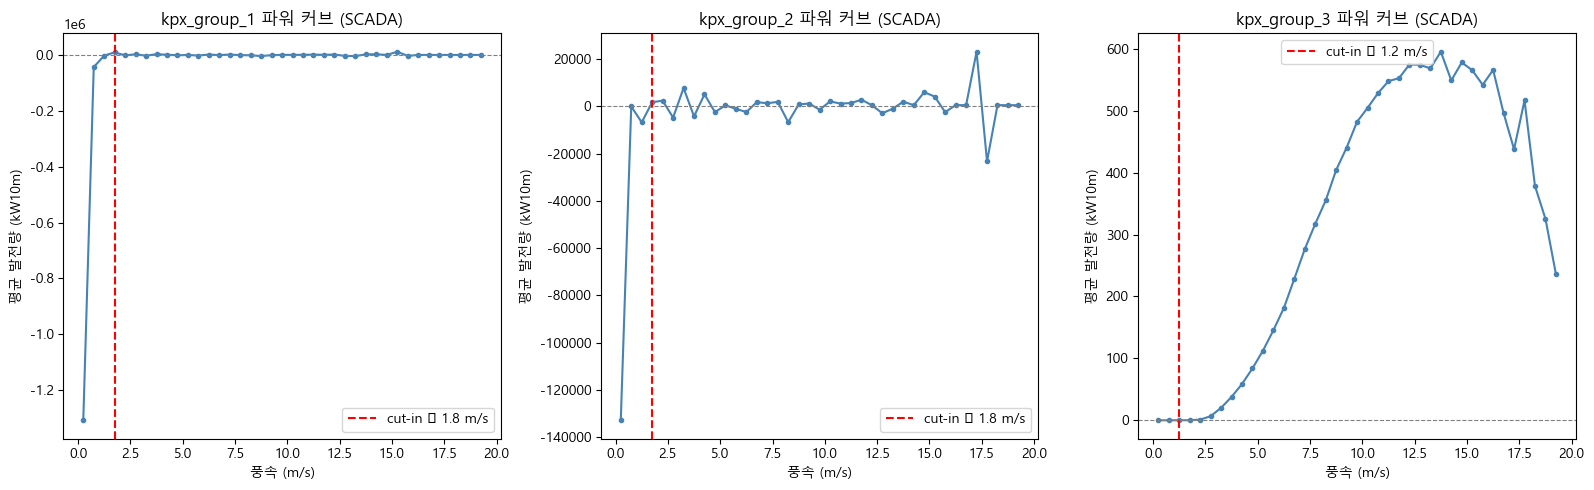

Cut-in 풍속: {'kpx_group_1': 1.75, 'kpx_group_2': 1.75, 'kpx_group_3': 1.25}


In [259]:
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['font.family'] = 'Malgun Gothic'
matplotlib.rcParams['axes.unicode_minus'] = False

groups = ['kpx_group_1', 'kpx_group_2', 'kpx_group_3']

# SCADA 풍속 구간별 평균 발전량 → cut-in 풍속 시각화
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
cutin_ws = {}

for i, grp in enumerate(groups):
    sc = scada_grp[grp].dropna()
    sc = sc.copy()
    sc['ws_bin'] = pd.cut(sc['ws_mean'], bins=np.arange(0, 20, 0.5))
    bin_mean = sc.groupby('ws_bin')['power_mean'].mean()

    axes[i].plot(
        [b.mid for b in bin_mean.index],
        bin_mean.values,
        marker='o', markersize=3, color='steelblue'
    )
    axes[i].axhline(0, color='gray', linestyle='--', linewidth=0.8)
    axes[i].set_title(f'{grp} 파워 커브 (SCADA)')
    axes[i].set_xlabel('풍속 (m/s)')
    axes[i].set_ylabel('평균 발전량 (kW10m)')

    positive_bins = [(b.mid, v) for b, v in zip(bin_mean.index, bin_mean.values)
                     if pd.notna(v) and v > 0]
    cutin = positive_bins[0][0] if positive_bins else 3.0
    cutin_ws[grp] = cutin
    axes[i].axvline(cutin, color='red', linestyle='--', label=f'cut-in ≈ {cutin:.1f} m/s')
    axes[i].legend()

plt.tight_layout()
plt.show()
print('Cut-in 풍속:', cutin_ws)

In [260]:
# ← 이 셀은 아래 "7. 테스트 예측" 직전에 실행하세요 (cell_model 이후)
# 셀 순서 문제로 인해 내용을 아래 셀로 이동했습니다
pass

In [261]:
pass  # 검증 셀 — cell_model 이후 별도 실행

In [262]:
group_col_map = {
    nearest_df.iloc[0]['kpx_group']: 'kpx_group_1',
    nearest_df.iloc[1]['kpx_group']: 'kpx_group_2',
    nearest_df.iloc[2]['kpx_group']: 'kpx_group_3',
}
print('그룹 매핑:', group_col_map)

train_datasets = {}
for grp, label_col in group_col_map.items():
    base = labels[['kst_dtm', label_col]].dropna()
    df = base.merge(
        ldaps_feats[grp], left_on='kst_dtm', right_on='forecast_kst_dtm', how='left'
    ).drop(columns='forecast_kst_dtm')
    df = df.merge(
        gfs_feats[grp], left_on='kst_dtm', right_on='forecast_kst_dtm', how='left'
    ).drop(columns='forecast_kst_dtm')

    # 시간 피처 (sin/cos 인코딩으로 주기성 반영)
    df['hour']         = df['kst_dtm'].dt.hour
    df['hour_sin']     = np.sin(2 * np.pi * df['hour'] / 24)
    df['hour_cos']     = np.cos(2 * np.pi * df['hour'] / 24)
    df['month']        = df['kst_dtm'].dt.month
    df['month_sin']    = np.sin(2 * np.pi * df['month'] / 12)
    df['month_cos']    = np.cos(2 * np.pi * df['month'] / 12)
    df['dayofyear']    = df['kst_dtm'].dt.dayofyear
    df['doy_sin']      = np.sin(2 * np.pi * df['dayofyear'] / 365)
    df['doy_cos']      = np.cos(2 * np.pi * df['dayofyear'] / 365)

    train_datasets[label_col] = df
    print(f'{label_col}: {df.shape}, null={df.isnull().sum().sum()}')

train_datasets['kpx_group_1'].head(3)

그룹 매핑: {1.0: 'kpx_group_1', 2.0: 'kpx_group_2', 3.0: 'kpx_group_3'}
kpx_group_1: (26200, 44), null=0
kpx_group_2: (26201, 44), null=0
kpx_group_3: (17538, 44), null=0


,kst_dtm,kpx_group_1,ldaps_ws10_ws,ldaps_ws10_ws3,ldaps_ws10_wd_sin,ldaps_ws10_wd_cos,ldaps_ws50max_ws,ldaps_ws50max_ws3,ldaps_ws50max_wd_sin,ldaps_ws50max_wd_cos,...,gfs_atmosphere_0_tcc,hour,hour_sin,hour_cos,month,month_sin,month_cos,dayofyear,doy_sin,doy_cos
0,2022-01-01 01:00:00,12004.421,4.899094,117.583781,0.987415,0.158148,7.358449,398.436234,0.989046,0.147609,...,60.2,1,0.258819,0.965926,1,0.5,0.866025,1,0.017213,0.999852
1,2022-01-01 02:00:00,12901.137,4.237866,76.109982,0.986134,0.165949,7.249851,381.054685,0.988802,0.149231,...,18.9,2,0.500000,0.866025,1,0.5,0.866025,1,0.017213,0.999852
2,2022-01-01 03:00:00,12091.200,4.054678,66.660562,0.968880,0.247531,5.680931,183.340603,0.989244,0.146272,...,19.1,3,0.707107,0.707107,1,0.5,0.866025,1,0.017213,0.999852


## 5-1. EDA — 발전량 분포 및 시간 패턴

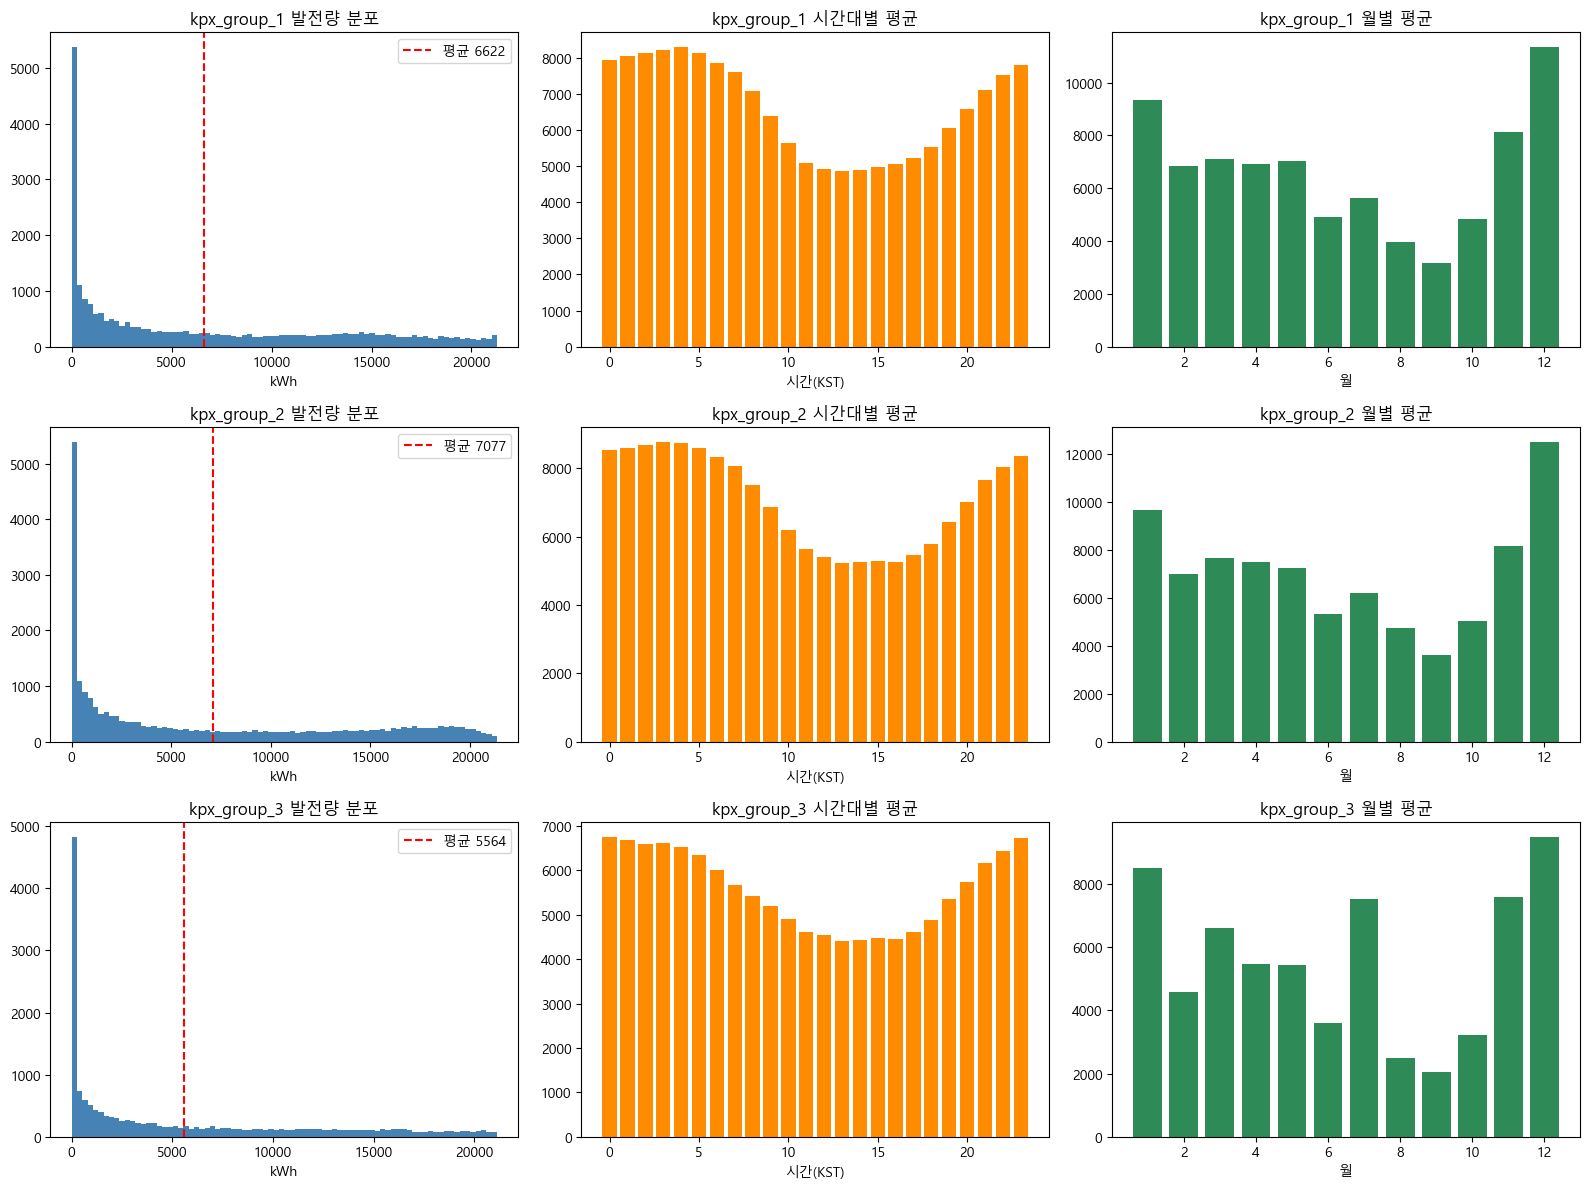

In [263]:
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['font.family'] = 'Malgun Gothic'
matplotlib.rcParams['axes.unicode_minus'] = False

fig, axes = plt.subplots(3, 3, figsize=(16, 12))
groups = ['kpx_group_1', 'kpx_group_2', 'kpx_group_3']
capacities = {'kpx_group_1': 21600, 'kpx_group_2': 21600, 'kpx_group_3': 21000}

for i, grp in enumerate(groups):
    df = train_datasets[grp]
    y  = df[grp]
    cap = capacities[grp]

    # 발전량 분포
    axes[i][0].hist(y, bins=80, color='steelblue', edgecolor='none')
    axes[i][0].set_title(f'{grp} 발전량 분포')
    axes[i][0].set_xlabel('kWh')
    axes[i][0].axvline(y.mean(), color='red', linestyle='--', label=f'평균 {y.mean():.0f}')
    axes[i][0].legend()

    # 시간대별 평균 발전량
    hourly = df.groupby('hour')[grp].mean()
    axes[i][1].bar(hourly.index, hourly.values, color='darkorange')
    axes[i][1].set_title(f'{grp} 시간대별 평균')
    axes[i][1].set_xlabel('시간(KST)')

    # 월별 평균 발전량
    monthly = df.groupby('month')[grp].mean()
    axes[i][2].bar(monthly.index, monthly.values, color='seagreen')
    axes[i][2].set_title(f'{grp} 월별 평균')
    axes[i][2].set_xlabel('월')

plt.tight_layout()
plt.show()

## 5-2. EDA — 풍속 vs 발전량 산점도 (핵심 관계)

사용 가능한 풍속 컬럼: ['ldaps_ws10_ws', 'ldaps_ws50max_ws', 'gfs_ws80_ws']


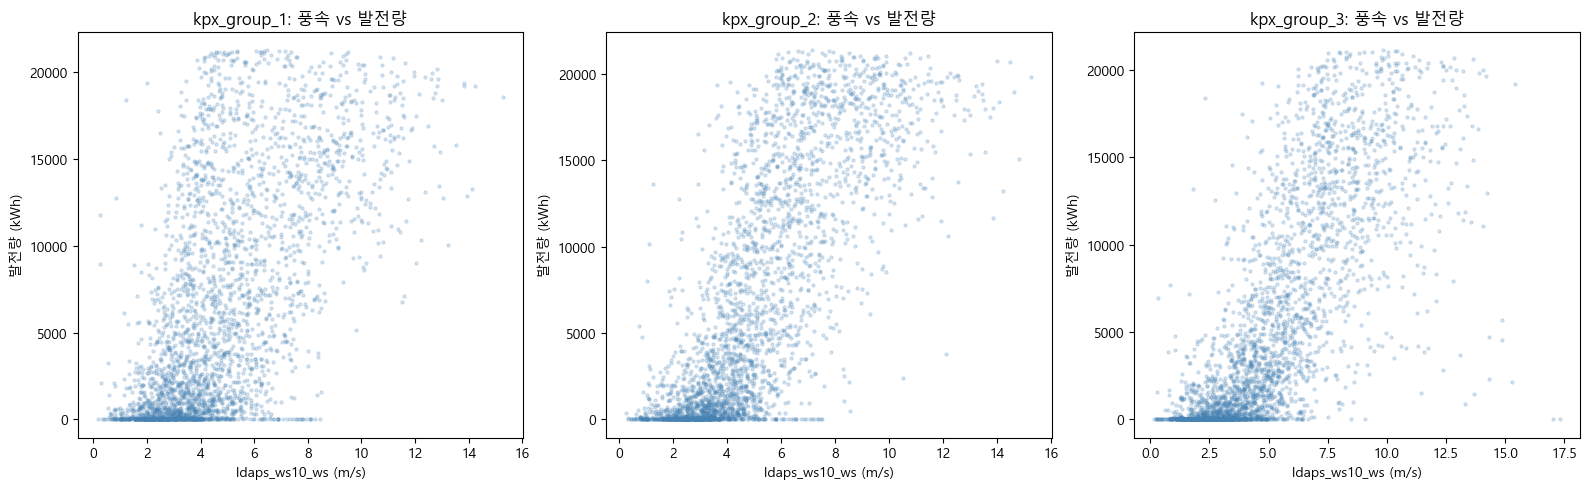


=== 풍속 컬럼과 발전량 상관계수 ===

kpx_group_1:
  ldaps_ws50max_ws                   : 0.6342
  gfs_ws10_ws                        : 0.6194
  gfs_ws100_ws                       : 0.6178
  gfs_ws80_ws                        : 0.6150
  ldaps_ws10_ws                      : 0.6149
  gfs_ws80_wd_sin                    : 0.5207

kpx_group_2:
  ldaps_ws10_ws                      : 0.7566
  ldaps_ws50max_ws                   : 0.7544
  gfs_ws100_ws                       : 0.6284
  gfs_ws10_ws                        : 0.6257
  gfs_ws80_ws                        : 0.6248
  ldaps_ws10_ws3                     : 0.5975

kpx_group_3:
  ldaps_ws50max_ws                   : 0.7795
  ldaps_ws10_ws                      : 0.7791
  ldaps_ws10_ws3                     : 0.6380
  ldaps_ws50max_ws3                  : 0.6283
  gfs_ws100_ws                       : 0.6251
  gfs_ws10_ws                        : 0.6238


In [264]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# 실제 존재하는 풍속 컬럼 확인
sample_df = train_datasets['kpx_group_1']
wind_candidates = ['ldaps_ws10_ws', 'ldaps_ws50max_ws', 'gfs_ws80_ws',
                   'ldaps_ws_10m', 'ldaps_ws_50m_max', 'gfs_ws_80m']
available_ws = [c for c in wind_candidates if c in sample_df.columns]
print('사용 가능한 풍속 컬럼:', available_ws)
ws_col = available_ws[0]  # 첫 번째 사용 가능한 컬럼

for i, grp in enumerate(groups):
    df = train_datasets[grp].sample(3000, random_state=42)
    axes[i].scatter(df[ws_col], df[grp], alpha=0.2, s=5, color='steelblue')
    axes[i].set_title(f'{grp}: 풍속 vs 발전량')
    axes[i].set_xlabel(f'{ws_col} (m/s)')
    axes[i].set_ylabel('발전량 (kWh)')

plt.tight_layout()
plt.show()

# 풍속 컬럼별 상관계수
print("\n=== 풍속 컬럼과 발전량 상관계수 ===")
for grp in groups:
    df = train_datasets[grp]
    ws_cols = [c for c in df.columns if 'ws' in c and c != grp]
    ws_corrs = {col: df[col].corr(df[grp]) for col in ws_cols}
    print(f"\n{grp}:")
    for col, corr in sorted(ws_corrs.items(), key=lambda x: -abs(x[1]))[:6]:
        print(f"  {col:35s}: {corr:.4f}")

## 5-3. EDA — 전체 피처 상관계수 히트맵

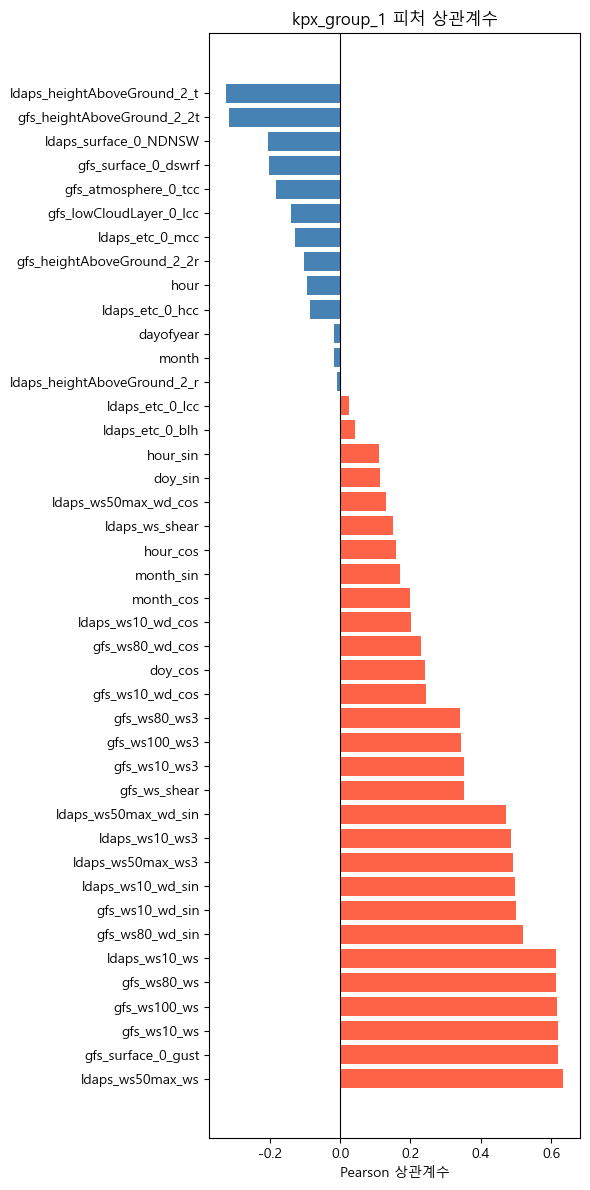

ldaps_ws50max_ws               0.634235
gfs_surface_0_gust             0.619629
gfs_ws10_ws                    0.619396
gfs_ws100_ws                   0.617837
gfs_ws80_ws                    0.614955
ldaps_ws10_ws                  0.614949
gfs_ws80_wd_sin                0.520669
gfs_ws10_wd_sin                0.499799
ldaps_ws10_wd_sin              0.496686
ldaps_ws50max_ws3              0.490962
ldaps_ws10_ws3                 0.485871
ldaps_ws50max_wd_sin           0.471962
gfs_ws_shear                   0.352611
gfs_ws10_ws3                   0.352239
gfs_ws100_ws3                  0.345010
gfs_ws80_ws3                   0.341541
gfs_ws10_wd_cos                0.244550
doy_cos                        0.242071
gfs_ws80_wd_cos                0.229222
ldaps_ws10_wd_cos              0.200742
month_cos                      0.198844
month_sin                      0.171376
hour_cos                       0.157656
ldaps_ws_shear                 0.150371
ldaps_ws50max_wd_cos           0.130663


In [265]:
TARGET = 'kpx_group_1'
df = train_datasets[TARGET]
feat_cols = [c for c in df.columns if c not in ['kst_dtm', TARGET]]

corr = df[feat_cols + [TARGET]].corr()[TARGET].drop(TARGET).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(6, 12))
colors = ['tomato' if v > 0 else 'steelblue' for v in corr.values]
ax.barh(corr.index, corr.values, color=colors)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_title(f'{TARGET} 피처 상관계수')
ax.set_xlabel('Pearson 상관계수')
plt.tight_layout()
plt.show()

print(corr.to_string())

## 5-4. EDA — LightGBM 피처 중요도 (모델 학습 후 실행)

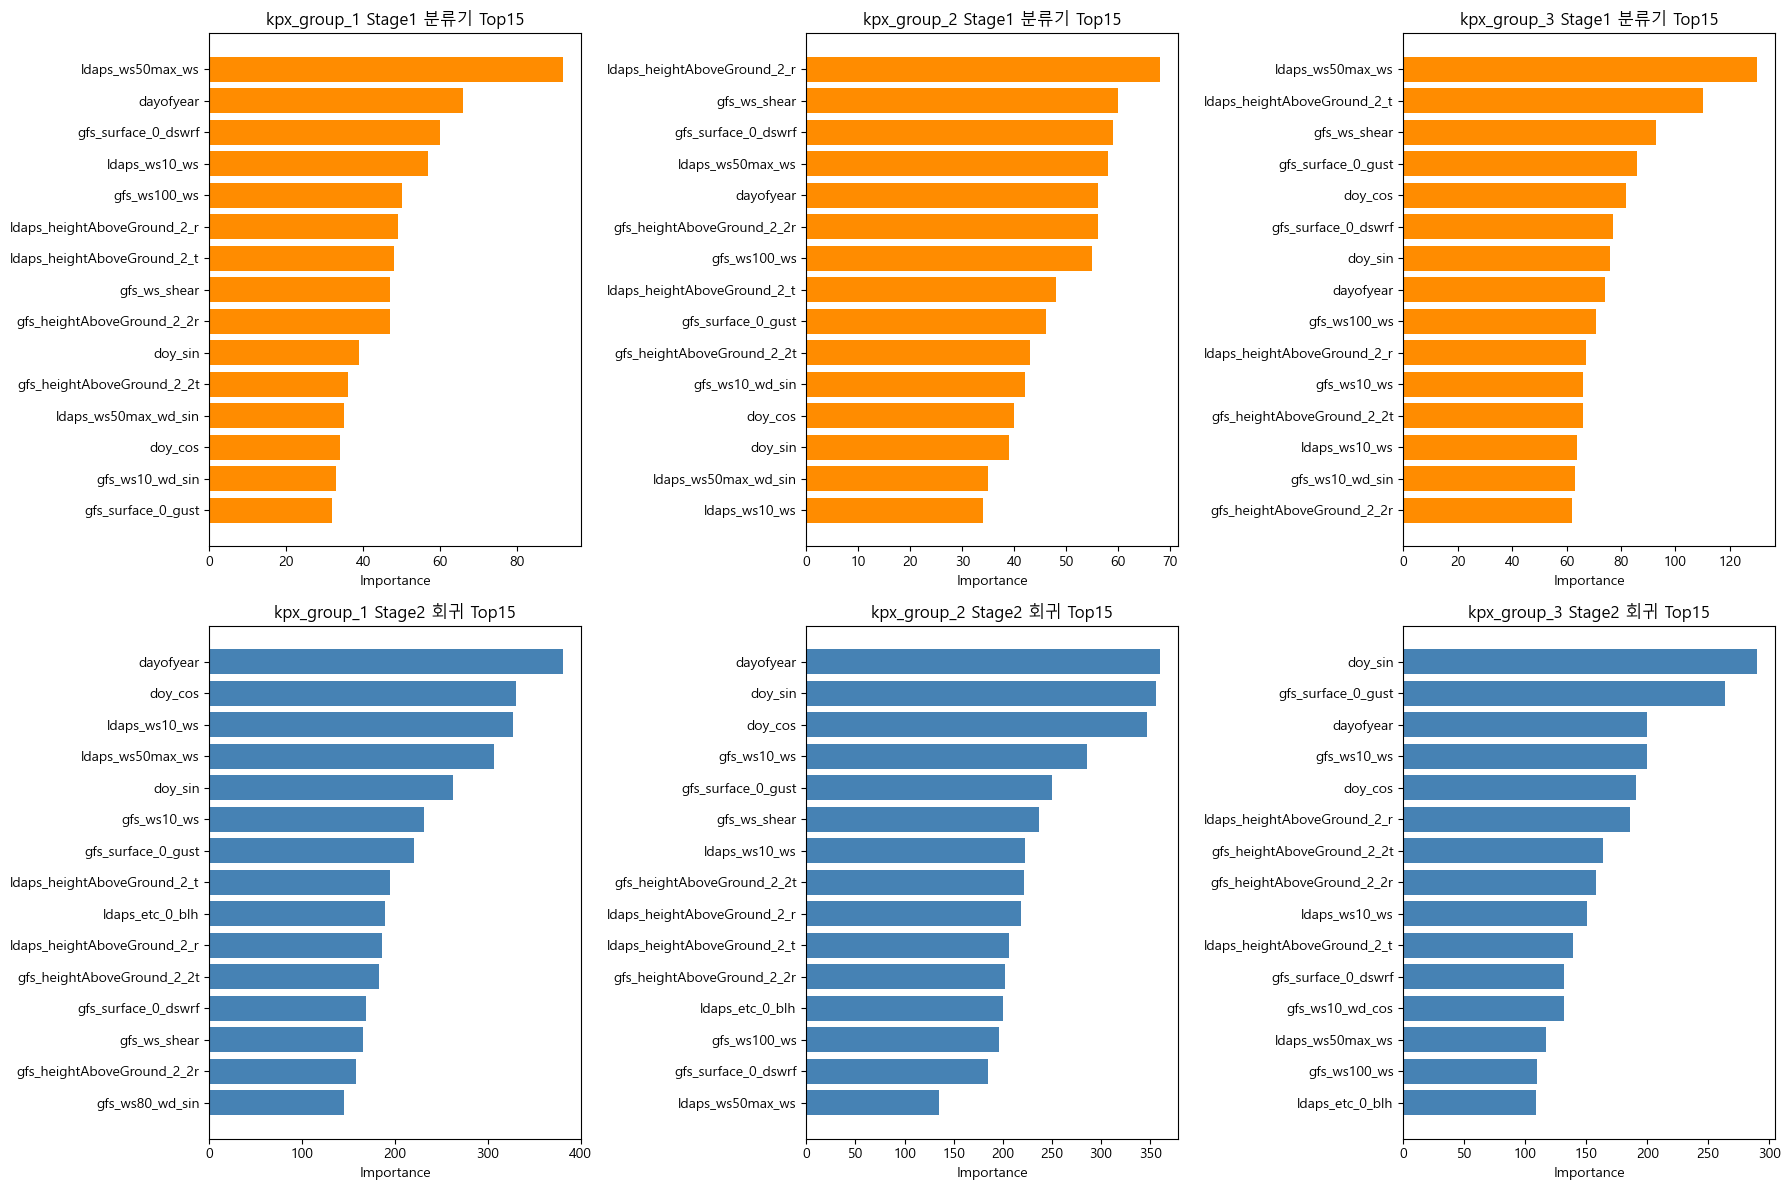

In [266]:
fig, axes = plt.subplots(2, 3, figsize=(18, 12))

for i, grp in enumerate(groups):
    feat_cols = [c for c in train_datasets[grp].columns if c not in ['kst_dtm', grp]]

    for j, (stage, key) in enumerate([('Stage1 분류기', 'clf'), ('Stage2 회귀', 'reg')]):
        model = models[grp][key]
        importance = pd.Series(model.feature_importances_, index=feat_cols).sort_values(ascending=True)
        top15 = importance.tail(15)
        axes[j][i].barh(top15.index, top15.values, color='steelblue' if key == 'reg' else 'darkorange')
        axes[j][i].set_title(f'{grp} {stage} Top15')
        axes[j][i].set_xlabel('Importance')

plt.tight_layout()
plt.show()

## 6. 베이스라인 모델 (LightGBM)

In [267]:
import lightgbm as lgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, f1_score
import warnings
warnings.filterwarnings('ignore')

# 2단계 모델
# Stage 1: 발전 여부 분류기 (power > 0 여부)
# Stage 2: 발전량 회귀 모델 (발전 구간만 학습)

GEN_THRESHOLD = 50   # 발전 중으로 판단하는 최소 발전량 (kWh)
CLF_PROB_THR  = 0.5  # 분류기 확률 임계값

models = {}       # {'kpx_group_1': {'clf': ..., 'reg': ...}}
capacities = {'kpx_group_1': 21600, 'kpx_group_2': 21600, 'kpx_group_3': 21000}

for label_col, df in train_datasets.items():
    feat_cols = [c for c in df.columns if c not in ['kst_dtm', label_col]]
    X = df[feat_cols]
    y = df[label_col]
    y_bin = (y > GEN_THRESHOLD).astype(int)  # Stage1 타깃

    X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, shuffle=False)
    _, _, yb_train, yb_val = train_test_split(X, y_bin, test_size=0.2, shuffle=False)

    cap = capacities[label_col]

    # ── Stage 1: 분류기 ──────────────────────────────────────
    clf = lgb.LGBMClassifier(
        n_estimators=500, learning_rate=0.05, num_leaves=63,
        random_state=42, n_jobs=-1, verbose=-1,
        scale_pos_weight=(yb_train == 0).sum() / (yb_train == 1).sum()
    )
    clf.fit(X_train, yb_train,
            eval_set=[(X_val, yb_val)],
            callbacks=[lgb.early_stopping(50, verbose=False), lgb.log_evaluation(-1)])

    clf_prob_val = clf.predict_proba(X_val)[:, 1]
    clf_pred_val = (clf_prob_val >= CLF_PROB_THR).astype(int)
    f1 = f1_score(yb_val, clf_pred_val)
    print(f'{label_col} Stage1 F1={f1:.4f} | '
          f'실제발전={yb_val.sum()} | 예측발전={clf_pred_val.sum()}')

    # ── Stage 2: 회귀 모델 (발전 구간만) ─────────────────────
    gen_mask_tr = yb_train == 1
    reg = lgb.LGBMRegressor(
        n_estimators=500, learning_rate=0.05, num_leaves=63,
        random_state=42, n_jobs=-1, verbose=-1
    )
    # val도 발전 구간만 사용
    gen_mask_val = yb_val == 1
    reg.fit(X_train[gen_mask_tr], y_train[gen_mask_tr],
            eval_set=[(X_val[gen_mask_val], y_val[gen_mask_val])],
            callbacks=[lgb.early_stopping(50, verbose=False), lgb.log_evaluation(-1)])

    # ── 최종 예측 조합 ────────────────────────────────────────
    reg_pred_val = reg.predict(X_val).clip(0, cap)
    final_pred   = np.where(clf_prob_val >= CLF_PROB_THR, reg_pred_val, 0.0)

    mae  = mean_absolute_error(y_val, final_pred)
    nmae = mae / cap * 100

    # 베이스라인 비교 (단일 회귀)
    reg_base = lgb.LGBMRegressor(n_estimators=300, learning_rate=0.05, num_leaves=63,
                                  random_state=42, n_jobs=-1, verbose=-1)
    reg_base.fit(X_train, y_train,
                 eval_set=[(X_val, y_val)],
                 callbacks=[lgb.early_stopping(50, verbose=False), lgb.log_evaluation(-1)])
    base_pred = reg_base.predict(X_val).clip(0, cap)
    mae_base  = mean_absolute_error(y_val, base_pred)

    print(f'  Stage2+분류기 MAE={mae:.1f} NMAE={nmae:.3f}% | 베이스라인 MAE={mae_base:.1f}')

    models[label_col] = {'clf': clf, 'reg': reg}
    print()

kpx_group_1 Stage1 F1=0.8960 | 실제발전=4352 | 예측발전=4030
  Stage2+분류기 MAE=1972.9 NMAE=9.134% | 베이스라인 MAE=1984.0

kpx_group_2 Stage1 F1=0.8894 | 실제발전=4354 | 예측발전=4027
  Stage2+분류기 MAE=1920.4 NMAE=8.891% | 베이스라인 MAE=1938.8

kpx_group_3 Stage1 F1=0.8671 | 실제발전=2601 | 예측발전=2254
  Stage2+분류기 MAE=1597.2 NMAE=7.606% | 베이스라인 MAE=1672.6



## 7. 테스트 예측 및 제출 파일 생성

In [268]:
BEST_PCT = {'kpx_group_1': 0.50, 'kpx_group_2': 0.70, 'kpx_group_3': 0.90}
ldaps_cutin = {}

# 실제 존재하는 풍속 컬럼명 자동 탐지
def get_ws_col(df):
    for c in ['ldaps_ws50max_ws', 'ldaps_ws_50m_max', 'ldaps_ws10_ws', 'ldaps_ws_10m']:
        if c in df.columns:
            return c
    return None

for label_col in ['kpx_group_1', 'kpx_group_2', 'kpx_group_3']:
    sc = scada_grp[label_col].dropna()
    ws_col = get_ws_col(train_datasets[label_col])
    if ws_col is None:
        ldaps_cutin[label_col] = 3.0
        print(f'{label_col}: 풍속 컬럼 없음 → default 3.0')
        continue

    df_ws = train_datasets[label_col][['kst_dtm', ws_col]].dropna()
    merged = df_ws.merge(sc[['kst_dtm', 'power_mean']], on='kst_dtm', how='inner')
    zero_ldaps = merged[merged['power_mean'] <= 0][ws_col]

    pct = BEST_PCT[label_col]
    threshold = zero_ldaps.quantile(pct) if len(zero_ldaps) > 0 else 3.0
    ldaps_cutin[label_col] = round(threshold, 2)
    print(f"{label_col}: 풍속컬럼={ws_col} | p{int(pct*100)} threshold={threshold:.2f} m/s")

print('\ncut-in 임계값:', ldaps_cutin)

kpx_group_1: 풍속컬럼=ldaps_ws50max_ws | p50 threshold=3.71 m/s
kpx_group_2: 풍속컬럼=ldaps_ws50max_ws | p70 threshold=4.63 m/s
kpx_group_3: 풍속컬럼=ldaps_ws50max_ws | p90 threshold=6.10 m/s

cut-in 임계값: {'kpx_group_1': 3.71, 'kpx_group_2': 4.63, 'kpx_group_3': 6.1}


In [269]:
ldaps_test = pd.read_csv(TEST / 'ldaps_test.csv', encoding='utf-8-sig', parse_dates=['forecast_kst_dtm'])
gfs_test   = pd.read_csv(TEST / 'gfs_test.csv',   encoding='utf-8-sig', parse_dates=['forecast_kst_dtm'])

ldaps_test = add_wind_features(ldaps_test, 'heightAboveGround_10_10u', 'heightAboveGround_10_10v', 'ws10')
ldaps_test = add_wind_features(ldaps_test, 'heightAboveGround_50_50MUmax', 'heightAboveGround_50_50MVmax', 'ws50max')
ldaps_test['ws_shear'] = ldaps_test['ws50max_ws'] / (ldaps_test['ws10_ws'] + 0.1)
ldaps_test['ws_10m']   = ldaps_test['ws10_ws']
ldaps_test['ws_50m_max'] = ldaps_test['ws50max_ws']

gfs_test = add_wind_features(gfs_test, 'heightAboveGround_10_10u', 'heightAboveGround_10_10v', 'ws10')
gfs_test = add_wind_features(gfs_test, 'heightAboveGround_80_u',   'heightAboveGround_80_v',   'ws80')
gfs_test = add_wind_features(gfs_test, 'heightAboveGround_100_100u', 'heightAboveGround_100_100v', 'ws100')
gfs_test['ws_shear'] = gfs_test['ws80_ws'] / (gfs_test['ws10_ws'] + 0.1)
gfs_test['ws_10m']  = gfs_test['ws10_ws']
gfs_test['ws_80m']  = gfs_test['ws80_ws']
gfs_test['ws_100m'] = gfs_test['ws100_ws']

print('테스트 데이터 로드 완료')

테스트 데이터 로드 완료


In [270]:
ldaps_test_feats = {}
gfs_test_feats   = {}

for _, row in nearest_df.iterrows():
    grp = row['kpx_group']
    avail_l = [c for c in ldaps_feat_cols if c in ldaps_test.columns or c in ['forecast_kst_dtm','grid_id']]
    avail_g = [c for c in gfs_feat_cols   if c in gfs_test.columns   or c in ['forecast_kst_dtm','grid_id']]

    ldaps_test_feats[grp] = (
        ldaps_test[ldaps_test['grid_id'] == row['ldaps_grid_id']][avail_l]
        .rename(columns=lambda c: f'ldaps_{c}' if c not in ['forecast_kst_dtm','grid_id'] else c)
        .drop(columns='grid_id')
    )
    gfs_test_feats[grp] = (
        gfs_test[gfs_test['grid_id'] == row['gfs_grid_id']][avail_g]
        .rename(columns=lambda c: f'gfs_{c}' if c not in ['forecast_kst_dtm','grid_id'] else c)
        .drop(columns='grid_id')
    )

# 테스트 피처에 파워커브 예측값 추가 (훈련과 동일한 컬럼명 'pc_pred')
label_cols = ['kpx_group_1', 'kpx_group_2', 'kpx_group_3']
for i, (_, row) in enumerate(nearest_df.iterrows()):
    grp       = row['kpx_group']
    label_col = label_cols[i]
    if label_col not in power_curves:
        continue

    fn     = power_curves[label_col]['fn']
    ws_col = power_curves[label_col]['ws_col']
    # 테스트 피처 컬럼명은 ldaps_ 접두사가 붙어 있음
    lf_col = f'ldaps_{ws_col}'

    lf_df = ldaps_test_feats[grp].copy()
    if lf_col in lf_df.columns:
        lf_df['pc_pred'] = fn(lf_df[lf_col].fillna(0)).clip(0)  # 훈련과 동일한 이름
    else:
        lf_df['pc_pred'] = 0.0
        print(f'  경고: {lf_col} 없음 → pc_pred=0')

    ldaps_test_feats[grp] = lf_df

print('테스트 피처 추출 + 파워커브(pc_pred) 적용 완료')

# 훈련/테스트 피처 수 검증
for i, (_, row) in enumerate(nearest_df.iterrows()):
    grp       = row['kpx_group']
    label_col = label_cols[i]
    tr_feats  = [c for c in train_datasets[label_col].columns if c not in ['kst_dtm', label_col]]
    print(f'{label_col}: 훈련 피처 수={len(tr_feats)}')

  경고: ldaps_ldaps_ws50max_ws 없음 → pc_pred=0
  경고: ldaps_ldaps_ws50max_ws 없음 → pc_pred=0
  경고: ldaps_ldaps_ws50max_ws 없음 → pc_pred=0
테스트 피처 추출 + 파워커브(pc_pred) 적용 완료
kpx_group_1: 훈련 피처 수=42
kpx_group_2: 훈련 피처 수=42
kpx_group_3: 훈련 피처 수=42


In [271]:
submission = pd.read_csv(BASE / 'sample_submission.csv', encoding='utf-8-sig', parse_dates=['forecast_kst_dtm'])

for label_col, model_dict in models.items():
    grp = [g for g, lc in group_col_map.items() if lc == label_col][0]
    clf = model_dict['clf']
    reg = model_dict['reg']

    test_df = submission[['forecast_kst_dtm']].merge(
        ldaps_test_feats[grp], on='forecast_kst_dtm', how='left'
    ).merge(
        gfs_test_feats[grp], on='forecast_kst_dtm', how='left'
    )
    test_df['hour']      = test_df['forecast_kst_dtm'].dt.hour
    test_df['hour_sin']  = np.sin(2 * np.pi * test_df['hour'] / 24)
    test_df['hour_cos']  = np.cos(2 * np.pi * test_df['hour'] / 24)
    test_df['month']     = test_df['forecast_kst_dtm'].dt.month
    test_df['month_sin'] = np.sin(2 * np.pi * test_df['month'] / 12)
    test_df['month_cos'] = np.cos(2 * np.pi * test_df['month'] / 12)
    test_df['dayofyear'] = test_df['forecast_kst_dtm'].dt.dayofyear
    test_df['doy_sin']   = np.sin(2 * np.pi * test_df['dayofyear'] / 365)
    test_df['doy_cos']   = np.cos(2 * np.pi * test_df['dayofyear'] / 365)

    # 훈련 피처 순서와 정확히 일치시킴
    train_feat_cols = [c for c in train_datasets[label_col].columns
                       if c not in ['kst_dtm', label_col]]
    # 테스트에 없는 컬럼은 0으로 채움
    for c in train_feat_cols:
        if c not in test_df.columns:
            test_df[c] = 0.0
            print(f'  {label_col}: 테스트에 없는 컬럼 0 처리 → {c}')

    feat_cols = train_feat_cols  # 훈련과 동일한 순서·컬럼

    clf_prob = clf.predict_proba(test_df[feat_cols])[:, 1]
    reg_pred = reg.predict(test_df[feat_cols]).clip(0, capacities[label_col])
    final_pred = np.where(clf_prob >= CLF_PROB_THR, reg_pred, 0.0)

    if label_col in ldaps_cutin:
        thr = ldaps_cutin[label_col]
        ws_col = get_ws_col(train_datasets[label_col])
        lf_col = f'ldaps_{ws_col}' if ws_col else None
        if lf_col and lf_col in test_df.columns:
            cutin_mask = test_df[lf_col].fillna(0) < thr
            final_pred[cutin_mask.values] = 0.0

    submission[label_col] = final_pred
    zero_pct = (final_pred == 0).mean() * 100
    print(f'{label_col} | 예측 평균={final_pred.mean():.1f} kWh | 0예측={zero_pct:.1f}%')

submission.to_csv('submission.csv', index=False, encoding='utf-8-sig')
print('\nsubmission.csv 저장 완료')
submission.head()

kpx_group_1 | 예측 평균=7371.6 kWh | 0예측=13.2%
kpx_group_2 | 예측 평균=7808.0 kWh | 0예측=14.4%
kpx_group_3 | 예측 평균=6281.1 kWh | 0예측=19.4%

submission.csv 저장 완료


,forecast_id,forecast_kst_dtm,kpx_group_1,kpx_group_2,kpx_group_3
0,forecast_0001,2025-01-01 01:00:00,18403.570816,18946.790366,16858.353358
1,forecast_0002,2025-01-01 02:00:00,18407.588492,18959.159552,17371.554042
2,forecast_0003,2025-01-01 03:00:00,15026.989310,17955.467925,15621.645939
3,forecast_0004,2025-01-01 04:00:00,16416.875738,18215.576519,13826.587294
4,forecast_0005,2025-01-01 05:00:00,15621.463225,18406.628033,13298.330863
